In [1]:

import kagglehub
jp797498e_twitter_entity_sentiment_analysis_path = kagglehub.dataset_download('jp797498e/twitter-entity-sentiment-analysis')

print('Data source import complete.')


Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Data source import complete.


In [2]:


import numpy as np
import pandas as pd



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/twitter-entity-sentiment-analysis/twitter_validation.csv
/kaggle/input/twitter-entity-sentiment-analysis/twitter_training.csv


In [3]:
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os

data = pd.read_csv(os.path.join(jp797498e_twitter_entity_sentiment_analysis_path, "twitter_training.csv"),
                   header=None)


data.columns = ['id', 'entity', 'sentiment', 'Review']

print("Shape:", data.shape)
data.head()

Shape: (74682, 4)


,id,entity,sentiment,Review
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [5]:
print(data['sentiment'].value_counts())
print()
print(data.info())
print()
print(data.describe())

sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         74682 non-null  int64 
 1   entity     74682 non-null  object
 2   sentiment  74682 non-null  object
 3   Review     73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None

                 id
count  74682.000000
mean    6432.586165
std     3740.427870
min        1.000000
25%     3195.000000
50%     6422.000000
75%     9601.000000
max    13200.000000


In [6]:

data = data.dropna(subset=['Review'])
data = data[data['sentiment'] != 'Irrelevant']
le = LabelEncoder()
data['sentiment_enc'] = le.fit_transform(data['sentiment'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


In [7]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = text.lower()
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return " ".join(tokens)


data['clean_text'] = data['Review'].apply(clean_text)
data[['Review', 'clean_text', 'sentiment']].head()

,Review,clean_text,sentiment
0,im getting on borderlands and i will murder yo...,getting borderlands murder,Positive
1,I am coming to the borders and I will kill you...,coming borders kill,Positive
2,im getting on borderlands and i will kill you ...,getting borderlands kill,Positive
3,im coming on borderlands and i will murder you...,coming borderlands murder,Positive
4,im getting on borderlands 2 and i will murder ...,getting borderlands murder,Positive


In [8]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True
)

X = vectorizer.fit_transform(data['clean_text'])
Y = data['sentiment_enc']
print("Feature matrix shape:", X.shape)

Feature matrix shape: (61121, 20000)


In [9]:

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 48896 samples | Test: 12225 samples


In [10]:

model = LinearSVC(C=1.0, max_iter=2000)
model.fit(X_train, Y_train)
print("Model trained successfully.")

Model trained successfully.


In [12]:
Y_pred = model.predict(X_test)

acc = accuracy_score(Y_test, Y_pred)
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(Y_test, Y_pred, target_names=le.classes_))

Accuracy: 0.8924 (89.24%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.93      0.90      4472
     Neutral       0.91      0.86      0.89      3622
    Positive       0.91      0.88      0.89      4131

    accuracy                           0.89     12225
   macro avg       0.89      0.89      0.89     12225
weighted avg       0.89      0.89      0.89     12225



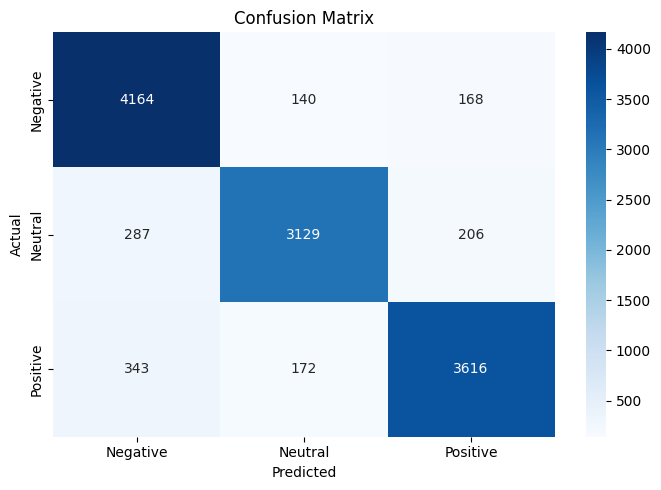

In [13]:
cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [14]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return le.inverse_transform([pred])[0]

samples = [
    "I absolutely love this game, it's amazing!",
    "This product is terrible and broken.",
    "It's okay, nothing special.",
    "Borderlands is the best game ever!"
]

for s in samples:
    print(f"Text: {s!r}  →  Sentiment: {predict_sentiment(s)}")

Text: "I absolutely love this game, it's amazing!"  →  Sentiment: Positive
Text: 'This product is terrible and broken.'  →  Sentiment: Negative
Text: "It's okay, nothing special."  →  Sentiment: Neutral
Text: 'Borderlands is the best game ever!'  →  Sentiment: Positive


In [11]:
from sklearn.linear_model import LogisticRegression


lr_model = LogisticRegression(max_iter=2000)

lr_model.fit(X_train, Y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [37]:


Y_pred_lr = lr_model.predict(X_test)



acc_lr = accuracy_score(Y_test, Y_pred_lr)

print(f"Logistic Regression Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)")

print()
print("Classification Report:")
print(classification_report(Y_test, Y_pred_lr, target_names=le.classes_))

Logistic Regression Accuracy: 0.8413 (84.13%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.90      0.86      4472
     Neutral       0.87      0.78      0.82      3622
    Positive       0.85      0.84      0.84      4131

    accuracy                           0.84     12225
   macro avg       0.84      0.84      0.84     12225
weighted avg       0.84      0.84      0.84     12225



In [32]:
from sklearn.model_selection import GridSearchCV

print("Starting Hyperparameter Tuning for Logistic Regression...")

param_grid = {
    'C': [0.1, 1.0, 10.0],
    'max_iter': [1000, 2000]
}


grid = GridSearchCV(LogisticRegression(), param_grid, cv=3, n_jobs=-1, verbose=1)


grid.fit(X_train, Y_train)

print(f"Best Parameters found: {grid.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid.best_score_:.4f}")


best_lr_model = grid.best_estimator_
tuned_acc = accuracy_score(Y_test, best_lr_model.predict(X_test))
print(f"Tuned Logistic Regression Test Accuracy: {tuned_acc:.4f}")

Starting Hyperparameter Tuning for Logistic Regression...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters found: {'C': 10.0, 'max_iter': 1000}
Best Cross-Validation Accuracy: 0.8658
Tuned Logistic Regression Test Accuracy: 0.8881


In [33]:


Y_pred_lr = best_lr_model.predict(X_test)



acc_lr = accuracy_score(Y_test, Y_pred_lr)

print(f"Logistic Regression Accuracy: {acc_lr:.4f} ({acc_lr*100:.2f}%)")

print()
print("Classification Report:")
print(classification_report(Y_test, Y_pred_lr, target_names=le.classes_))

Logistic Regression Accuracy: 0.8881 (88.81%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.93      0.90      4472
     Neutral       0.91      0.86      0.88      3622
    Positive       0.90      0.87      0.88      4131

    accuracy                           0.89     12225
   macro avg       0.89      0.89      0.89     12225
weighted avg       0.89      0.89      0.89     12225



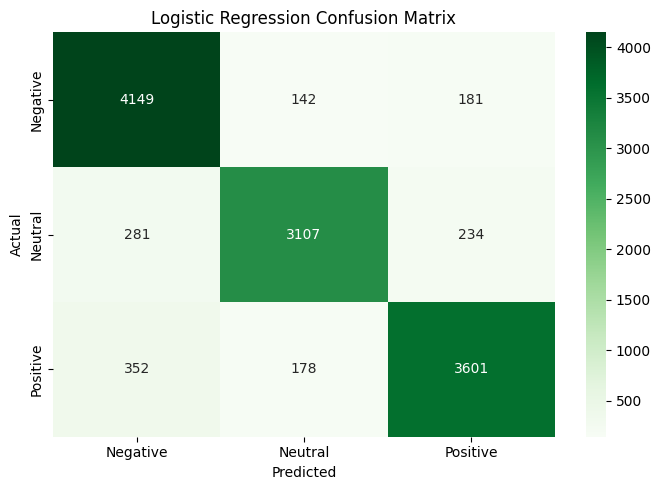

In [34]:


cm_lr = confusion_matrix(Y_test, Y_pred_lr)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()

In [35]:
def predict_sentiment_lr(text):

    cleaned = clean_text(text)

    vec = vectorizer.transform([cleaned])

    pred = best_lr_model.predict(vec)[0]

    return le.inverse_transform([pred])[0]



for s in samples:
    print(f"Text: {s!r} → Sentiment: {predict_sentiment_lr(s)}")

Text: "I absolutely love this game, it's amazing!" → Sentiment: Positive
Text: 'This product is terrible and broken.' → Sentiment: Negative
Text: "It's okay, nothing special." → Sentiment: Neutral
Text: 'Borderlands is the best game ever!' → Sentiment: Positive


In [18]:
!pip install streamlit

In [19]:
!pip install streamlit pyngrok kagglehub nltk scikit-learn seaborn matplotlib --quiet

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import kagglehub

from nltk.corpus import stopwords
import nltk

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

st.set_page_config(
    page_title="Twitter Sentiment Analysis",
    page_icon="🧠",
    layout="wide"
)

st.markdown(
    """
    <style>
    .main {
        background-color: #0E1117;
    }
    .title {
        font-size: 45px;
        font-weight: bold;
        color: #00FFAA;
        text-align: center;
    }
    .subtitle {
        font-size: 20px;
        color: #CCCCCC;
        text-align: center;
        margin-bottom: 30px;
    }
    .prediction-box {
        padding: 20px;
        border-radius: 15px;
        text-align: center;
        font-size: 28px;
        font-weight: bold;
        margin-top: 20px;
    }
    </style>
    """,
    unsafe_allow_html=True
)

st.markdown(
    '<div class="title">🧠 Twitter Sentiment Analysis</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">LinearSVC + TF-IDF NLP Model</div>',
    unsafe_allow_html=True
)

nltk.download('stopwords', quiet=True)
STOPWORDS = set(stopwords.words('english'))

@st.cache_data
def load_data():
    path = kagglehub.dataset_download('jp797498e/twitter-entity-sentiment-analysis')
    data = pd.read_csv(f"{path}/twitter_training.csv", header=None)
    data.columns = ['id', 'entity', 'sentiment', 'Review']
    data = data.dropna(subset=['Review'])
    data = data[data['sentiment'] != 'Irrelevant']
    return data

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = text.lower()
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return " ".join(tokens)




@st.cache_resource
def train_model():
    data = load_data()

    le = LabelEncoder()
    data['sentiment_enc'] = le.fit_transform(data['sentiment'])
    data['clean_text'] = data['Review'].apply(clean_text)

    vectorizer = TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.85,
        sublinear_tf=True
    )

    X = vectorizer.fit_transform(data['clean_text'])
    Y = data['sentiment_enc']

    # For the web app, we train on the full dataset
    model = LinearSVC(C=1.0, max_iter=2000)
    model.fit(X, Y)

    return model, vectorizer, le, data, X

with st.spinner("Loading and Training Model (This happens only once)..."):
    model, vectorizer, le, data, X = train_model()




st.sidebar.title("📊 Model Stats")
st.sidebar.write(f"Dataset Size: {data.shape[0]}")
st.sidebar.write(f"Features: {X.shape[1]}")
st.sidebar.write("Model: LinearSVC")

st.subheader("✍️ Enter Text")
user_input = st.text_area("Type text here:", height=180)

if st.button("🔍 Predict Sentiment"):
    if user_input.strip() == "":
        st.warning("Please enter text.")
    else:
        cleaned = clean_text(user_input)
        vec = vectorizer.transform([cleaned])
        pred = model.predict(vec)[0]
        sentiment = le.inverse_transform([pred])[0]

        if sentiment.lower() == 'positive':
            color = '#00FF99'
            emoji = '😊'
        elif sentiment.lower() == 'negative':
            color = '#FF4B4B'
            emoji = '😠'
        else:
            color = '#FFD700'
            emoji = '😐'

        st.markdown(
            f'''
            <div class="prediction-box" style="background-color:#1E1E1E;color:{color};">
                {emoji} {sentiment}
            </div>
            ''',
            unsafe_allow_html=True
        )

st.markdown("---")
st.subheader("📝 Example Inputs")
st.info("I absolutely love this game!")
st.info("This product is terrible and broken.")
st.info("The game crashes every time.")

Overwriting app.py


In [36]:
import time
from pyngrok import ngrok


!pkill ngrok
!pkill streamlit


NGROK_AUTH_TOKEN = "32SfDFIZs5KHg4jrKtiJB9jE86k_37UNkxJoxRzMo6M9TFePK"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)


!nohup streamlit run app.py --server.port 8501 --server.address localhost > logs.txt 2>&1 &


print("Waiting for Streamlit to start...")
time.sleep(5)


public_url = ngrok.connect(8501)

print("🚀 Streamlit App URL:")
print(public_url)

Waiting for Streamlit to start...
🚀 Streamlit App URL:
NgrokTunnel: "https://50b7-35-198-246-127.ngrok-free.app" -> "http://localhost:8501"
